# Projekt 1.1 — Der Lügendetektor für Mittelwerte

**Phase 1: Deskriptive Statistik & EDA · Schwierigkeit ⭐**

**Konzepte:** Mittelwert (mean), Median, Modus (mode), Schiefe (skewness), Ausreißer (outliers)


## 1. Fragestellung

> **Kann eine einzige Kennzahl (Mittelwert *oder* Median) eine Gehaltsverteilung ehrlich zusammenfassen — und wann lügt welche?**

Wir bauen drei Gehaltswelten, deren *Wahrheit wir kennen*, und prüfen, wo Mittelwert und Median die Realität verzerren.


## 2. Intuition zuerst

**Die Kneipen-Analogie.** Zehn normale Leute sitzen in einer Kneipe. Elon Musk kommt herein. Der *Mittelwert* des Vermögens im Raum sagt jetzt: „alle Milliardäre". Der *Median* — die Person genau in der Mitte der Reihe — zuckt nicht mal. Der Mittelwert ist der **Schwerpunkt** (ein einziger Extremwert kippt ihn), der Median ist der **mittlere Rang** (robust gegen Ausreißer).

**Drei Verteilungsformen, drei Lügen:**

| Form | mean vs. median | Wer lügt? |
|---|---|---|
| symmetrisch | mean ≈ median | kaum Spielraum |
| rechtsschief (Superreiche) | mean ≫ median | der **Mittelwert** täuscht Wohlstand vor |
| bimodal (zwei Gruppen) | beide im leeren Tal | **beide** — niemand verdient „den Schnitt" |

**Vorhersage (vor dem Rechnen notieren):** Bei welchem Datensatz wird der Abstand zwischen mean und median am größten? Und in welchem beschreibt *keine* der beiden Zahlen eine reale Person gut?


## 3. Setup

Wir laden die gemeinsamen Repo-Helfer (`utils`) und den projekteigenen Datengenerator. Reproduzierbarkeit ist Pflicht: alle Zufallszahlen kommen aus einem einzigen gesäten Generator (Seed 42), definiert in `data/generate_data.py`.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Repo-Root (zwei Ebenen hoch) und den Datenordner in den Importpfad legen.
REPO_ROOT = Path.cwd().parents[1]
sys.path.append(str(REPO_ROOT))
sys.path.append(str(Path.cwd() / "data"))

from utils import apply_house_style, add_truth_line   # gemeinsame Helfer
import generate_data as gd                             # projekteigener DGP

apply_house_style()
print("numpy", np.__version__, "| Seed:", gd.SEED, "| n pro Datensatz:", gd.N)

numpy 2.3.5 | Seed: 42 | n pro Datensatz: 5000


## 4. Daten — und der *wahre* Datengenerierungsprozess (DGP)

Der große Vorteil simulierter Daten: **wir kennen die Wahrheit.** Hier ist sie explizit:

- **`symmetric`** — `Normal(μ=45.000, σ=8.000)`, bei 20.000 € gekappt. Für die Normalverteilung gilt exakt **Erwartungswert = Median = μ**.
- **`right_skewed`** — Lognormal mit **Median = exp(μ_log) = 38.000 €**, σ_log = 0.55, PLUS 5 „Superreiche" (2–15 Mio. €). Analytisch ist der Lognormal-**Mittelwert = exp(μ_log + σ_log²/2) > Median**.
- **`bimodal`** — Mischung: 60 % `Normal(31.000, 4.000)` (Pflege/Handel) + 40 % `Normal(66.000, 9.000)` (IT/Ingenieurwesen). Zwei Gipfel, ein Tal bei ~48.000 €.


In [2]:
data = gd.generate_all()          # dict: name -> np.ndarray der Jahresgehälter
for name, values in data.items():
    print(f"{name:13s} n={len(values):5d}  "
          f"min={values.min():8,.0f}  max={values.max():14,.0f}")

symmetric     n= 5000  min=  20,000  max=        72,632
right_skewed  n= 5000  min=   3,399  max=     7,213,983
bimodal       n= 5000  min=  20,000  max=        93,975


## 5. Die naive (falsche) Herangehensweise

Ein Journalist bekommt die Rohdaten und macht, was fast jeder macht: *„Ich nehme den Durchschnitt."* Schauen wir, was dabei herauskommt — und halten es gegen das, was ein Mensch als „typisch" empfinden würde.


In [3]:
for name, values in data.items():
    schnitt = values.mean()
    print(f"{name:13s}: 'Das Durchschnittsgehalt beträgt {schnitt:,.0f} €.'")

symmetric    : 'Das Durchschnittsgehalt beträgt 44,842 €.'
right_skewed : 'Das Durchschnittsgehalt beträgt 49,625 €.'
bimodal      : 'Das Durchschnittsgehalt beträgt 45,585 €.'


Schon hier riecht es verdächtig: Beim rechtsschiefen und beim bimodalen Datensatz behauptet der „Durchschnitt" eine Zahl, die — wie wir gleich sehen — kaum jemand tatsächlich verdient. Der Durchschnitt ist nicht *falsch berechnet*, er ist die *falsche Zusammenfassung*.


## 6. Kernanalyse — die Kennzahlen von Hand

Zuerst implementieren wir Mittelwert, Median, Modus und Schiefe selbst (mit Docstring, der die Formel erklärt). Danach (Abschnitt 7) verifizieren wir gegen NumPy/SciPy.


In [4]:
def mean_by_hand(x: np.ndarray) -> float:
    """Arithmetischer Mittelwert = Summe / Anzahl.

    Der 'Schwerpunkt' der Daten: Σx_i / n. Jeder Wert zieht mit vollem Gewicht
    — deshalb kann ein einziger Extremwert ihn beliebig weit verschieben.
    """
    x = np.asarray(x, dtype=float)
    return float(x.sum() / x.size)


def median_by_hand(x: np.ndarray) -> float:
    """Median = mittlerer Wert der sortierten Daten.

    Alle der Größe nach aufstellen; bei ungerader Anzahl der mittlere Wert,
    bei gerader das Mittel der beiden mittleren. Nur der *Rang* zählt, nicht die
    *Höhe* der Extreme -> robust gegen Ausreißer.
    """
    xs = np.sort(np.asarray(x, dtype=float))
    n = xs.size
    mid = n // 2
    if n % 2 == 1:
        return float(xs[mid])
    return float((xs[mid - 1] + xs[mid]) / 2.0)


def mode_by_hand(x: np.ndarray, bins: int = 60) -> float:
    """Modus für stetige Daten via Histogramm: Mitte des häufigsten Bins.

    'Modus' = häufigster Wert. Bei stetigen Daten ist kein Einzelwert doppelt,
    deshalb binnen wir und nehmen die Mitte des Bins mit den meisten Beobachtungen.
    Das ist der 'typischste' Bereich — bei mehreren Gipfeln gibt es aber mehrere!
    """
    counts, edges = np.histogram(np.asarray(x, dtype=float), bins=bins)
    i = int(np.argmax(counts))
    return float((edges[i] + edges[i + 1]) / 2.0)


def skewness_by_hand(x: np.ndarray) -> float:
    """Fisher-Pearson-Schiefe g1 = m3 / m2**1.5.

    m_k = (1/n) Σ (x_i - x̄)^k sind die zentralen Momente. g1 misst die Asymmetrie:
    g1 > 0 -> langer rechter Schwanz (mean > median), g1 < 0 -> linker Schwanz,
    g1 ≈ 0 -> symmetrisch. Genau dieses Vorzeichen sagt voraus, in welche
    Richtung der Mittelwert 'lügt'.
    """
    x = np.asarray(x, dtype=float)
    xbar = mean_by_hand(x)
    m2 = np.mean((x - xbar) ** 2)
    m3 = np.mean((x - xbar) ** 3)
    return float(m3 / m2 ** 1.5)


Jetzt eine Kennzahl-Tabelle für alle drei Datensätze:

In [5]:
rows = []
for name, values in data.items():
    rows.append({
        "Datensatz": name,
        "Mittelwert": mean_by_hand(values),
        "Median": median_by_hand(values),
        "Modus": mode_by_hand(values),
        "Schiefe g1": skewness_by_hand(values),
        "mean - median": mean_by_hand(values) - median_by_hand(values),
    })
summary = pd.DataFrame(rows).set_index("Datensatz")
summary.round(2)

,Mittelwert,Median,Modus,Schiefe g1,mean - median
Datensatz,,,,,
symmetric,44841.85,44966.71,47631.99,0.01,-124.86
right_skewed,49625.03,37590.85,63487.51,33.88,12034.17
bimodal,45585.02,35360.11,30479.85,0.57,10224.91


## 7. Verifikation

**(a) Hand-Implementierung vs. Bibliothek.** Unsere Funktionen müssen exakt das liefern, was NumPy/SciPy liefern — sonst haben wir einen Fehler.


In [6]:
for name, values in data.items():
    assert np.isclose(mean_by_hand(values), np.mean(values)), name
    assert np.isclose(median_by_hand(values), np.median(values)), name
    assert np.isclose(skewness_by_hand(values), stats.skew(values)), name
print("Alle Hand-Implementierungen stimmen mit NumPy/SciPy überein. ✅")

Alle Hand-Implementierungen stimmen mit NumPy/SciPy überein. ✅


**(b) Simulation vs. analytische Formel.** Für die Lognormal-*Basis* (ohne Superreiche) kennen wir die Wahrheit in geschlossener Form:
$$\text{Median} = e^{\mu},\qquad \text{Mittelwert} = e^{\mu + \sigma^2/2}.$$
Wir ziehen eine große Stichprobe und prüfen, ob die empirischen Werte gegen die Formeln konvergieren.


In [7]:
mu_log, sigma_log = np.log(38_000), 0.55
rng = np.random.default_rng(0)
big = rng.lognormal(mu_log, sigma_log, size=1_000_000)   # nur Basis, keine Superreichen

analytic_median = np.exp(mu_log)
analytic_mean = np.exp(mu_log + sigma_log**2 / 2)
print(f"Median   — Formel: {analytic_median:12,.0f} €   Simulation: {np.median(big):12,.0f} €")
print(f"Mittelw. — Formel: {analytic_mean:12,.0f} €   Simulation: {big.mean():12,.0f} €")
print(f"\nSchon OHNE Superreiche liegt der Mittelwert {analytic_mean - analytic_median:,.0f} € "
      f"über dem Median — allein durch die Schiefe der Lognormalverteilung.")

Median   — Formel:       38,000 €   Simulation:       38,020 €
Mittelw. — Formel:       44,205 €   Simulation:       44,237 €

Schon OHNE Superreiche liegt der Mittelwert 6,205 € über dem Median — allein durch die Schiefe der Lognormalverteilung.


## 8. Visualisierung — *warum* die Kennzahlen auseinanderlaufen

**Plot 1: Die drei Verteilungen mit Mittelwert und Median.** Für den rechtsschiefen Datensatz beschneiden wir die x-Achse (die Superreichen liegen bei Millionen — sonst sähe man nur einen Balken ganz links und viel Leere; genau *das* ist die Lehre und wird im Titel benannt).


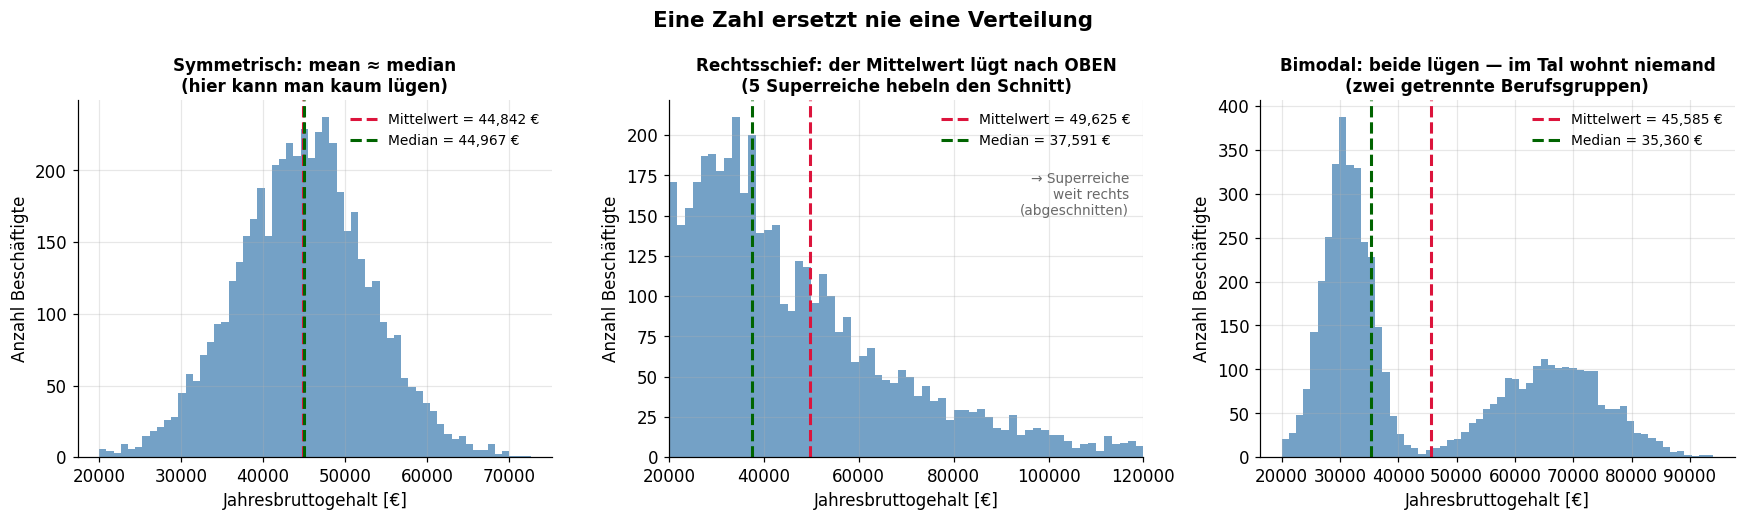

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

configs = [
    ("symmetric",    "Symmetrisch: mean ≈ median\n(hier kann man kaum lügen)", None),
    ("right_skewed", "Rechtsschief: der Mittelwert lügt nach OBEN\n(5 Superreiche hebeln den Schnitt)", (20_000, 120_000)),
    ("bimodal",      "Bimodal: beide lügen — im Tal wohnt niemand\n(zwei getrennte Berufsgruppen)", None),
]

for ax, (name, title, xlim) in zip(axes, configs):
    values = data[name]
    ax.hist(values, bins=60, range=xlim, color="steelblue", alpha=0.75)
    add_truth_line(ax, mean_by_hand(values), label=f"Mittelwert = {mean_by_hand(values):,.0f} €", color="crimson")
    add_truth_line(ax, median_by_hand(values), label=f"Median = {median_by_hand(values):,.0f} €", color="darkgreen")
    if xlim:
        ax.set_xlim(*xlim)
        ax.text(0.97, 0.80, "→ Superreiche\nweit rechts\n(abgeschnitten)",
                transform=ax.transAxes, ha="right", va="top", fontsize=9, color="dimgray")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Jahresbruttogehalt [€]")
    ax.set_ylabel("Anzahl Beschäftigte")
    ax.legend(fontsize=9)

fig.suptitle("Eine Zahl ersetzt nie eine Verteilung", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**Plot 2: Der Hebel des Ausreißers.** Wir entfernen die 5 Superreichen aus dem rechtsschiefen Datensatz und schauen, wie weit sich Mittelwert und Median bewegen. Das macht die *Robustheit* des Medians sichtbar.


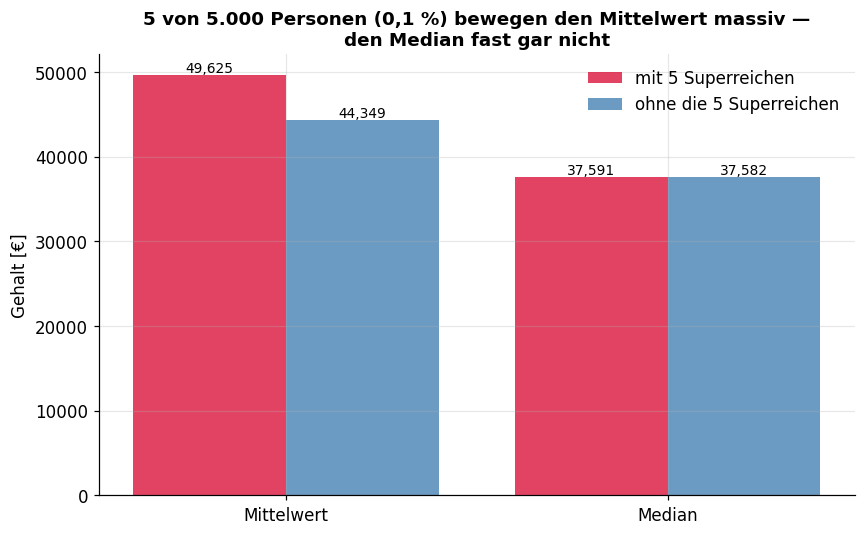

Mittelwert fällt um 5,276 €, Median nur um 9 €, wenn man 0,1 % der Daten entfernt.


In [9]:
rs = data["right_skewed"]
# Die 5 größten Werte sind unsere Superreichen (per Konstruktion die Extreme).
threshold = np.sort(rs)[-6]                 # sechstgrößter Wert als Grenze
without = rs[rs <= threshold]

labels = ["Mittelwert", "Median"]
mit    = [mean_by_hand(rs),      median_by_hand(rs)]
ohne   = [mean_by_hand(without), median_by_hand(without)]

fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(len(labels))
ax.bar(xpos - 0.2, mit,  width=0.4, label="mit 5 Superreichen", color="crimson", alpha=0.8)
ax.bar(xpos + 0.2, ohne, width=0.4, label="ohne die 5 Superreichen", color="steelblue", alpha=0.8)
for i, (m, o) in enumerate(zip(mit, ohne)):
    ax.text(i - 0.2, m, f"{m:,.0f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + 0.2, o, f"{o:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_ylabel("Gehalt [€]")
ax.set_title("5 von 5.000 Personen (0,1 %) bewegen den Mittelwert massiv —\nden Median fast gar nicht", fontsize=12)
ax.legend()
fig.tight_layout()
plt.show()

print(f"Mittelwert fällt um {mit[0]-ohne[0]:,.0f} €, Median nur um {mit[1]-ohne[1]:,.0f} €, "
      f"wenn man 0,1 % der Daten entfernt.")

## 9. Die Schlagzeilen — mit jeder Kennzahl lügen

Aufgabe: pro Datensatz eine Schlagzeile, die *mit dem Mittelwert* täuscht, und eine, die *mit dem Median* täuscht. Alle Zahlen sind **korrekt berechnet** — die Lüge steckt in der *Auswahl* der Kennzahl und im weggelassenen Kontext.


In [10]:
def headlines(name):
    v = data[name]
    return mean_by_hand(v), median_by_hand(v)

for name in data:
    mean, median = headlines(name)
    print(f"=== {name.upper()} ===")
    print(f"  🟥 Lüge mit dem Mittelwert: 'Durchschnittsgehalt bei {mean:,.0f} € — uns geht es gut!'")
    print(f"  🟩 Lüge mit dem Median:     'Jede zweite Person verdient höchstens {median:,.0f} € — "
          f"die Mitte stagniert!'")
    print()

=== SYMMETRIC ===
  🟥 Lüge mit dem Mittelwert: 'Durchschnittsgehalt bei 44,842 € — uns geht es gut!'
  🟩 Lüge mit dem Median:     'Jede zweite Person verdient höchstens 44,967 € — die Mitte stagniert!'

=== RIGHT_SKEWED ===
  🟥 Lüge mit dem Mittelwert: 'Durchschnittsgehalt bei 49,625 € — uns geht es gut!'
  🟩 Lüge mit dem Median:     'Jede zweite Person verdient höchstens 37,591 € — die Mitte stagniert!'

=== BIMODAL ===
  🟥 Lüge mit dem Mittelwert: 'Durchschnittsgehalt bei 45,585 € — uns geht es gut!'
  🟩 Lüge mit dem Median:     'Jede zweite Person verdient höchstens 35,360 € — die Mitte stagniert!'



**Warum das Lügen ist:**

- **symmetric:** Beide Zahlen sind ehrlich (mean ≈ median). Die „Lüge" wäre höchstens Rosinenpickerei um wenige Euro — ein gutes Kontrastbeispiel: *hier gibt es kaum Manipulationsspielraum.*
- **right_skewed:** Der Mittelwert (~49.600 €) suggeriert Wohlstand, den die 5 Superreichen erzeugen; die *Hälfte* verdient unter ~37.600 €. Umgekehrt verschweigt eine reine Median-Schlagzeile, dass am oberen Ende enorme Summen fließen.
- **bimodal:** *Beide* Zahlen fallen in das Tal zwischen den Gruppen — die Schlagzeile „typisch verdient man ~45.000 €" beschreibt eine Person, die es praktisch nicht gibt. Ehrlich wäre nur: *„Es gibt zwei getrennte Gruppen."*


## 10. Interpretation *(von dir auszufüllen — 3–5 Sätze, Alltagssprache)*

> _Schreibe hier in eigenen Worten: Wann ist der Mittelwert die ehrlichere Kennzahl, wann der Median? Was ist die eine Sache, die *keine* der beiden Zahlen leisten kann? Vermeide „beweist"; formuliere präzise._

*(Platzhalter — deine Interpretation kommt in `NOTIZEN.md`.)*


## 11. Grenzen & Fallen

- **Der Modus ist bei stetigen Daten binning-abhängig.** Ändere `bins`, und der Modus wandert. Bei bimodalen Daten liefert unsere Funktion nur *einen* Gipfel, obwohl es zwei gibt — ein einzelner „häufigster Wert" ist dann selbst irreführend.
- **Median ist robust, aber nicht allwissend.** Er ignoriert die gesamte Form der Ränder. Zwei völlig verschiedene Verteilungen können denselben Median haben (Vorschau auf Projekt 1.3, Anscombe/Datasaurus).
- **Schiefe-Kennzahl reagiert selbst empfindlich auf Ausreißer** (dritte Potenz!). Sie ist ein Indikator, kein Beweis.
- **„Symmetrisch" ist eine Annahme.** Unsere Kappung bei 20.000 € erzeugt eine winzige Schiefe — schon reale Daten sind selten perfekt symmetrisch.


## 12. Stretch Goal — automatische „Ehrlichkeits"-Heuristik

Baue eine Funktion, die entscheidet, ob Mittelwert oder Median die *ehrlichere* Zusammenfassung ist — und die *warnt*, wenn **keine** Einzelzahl genügt (bimodal!).

**Heuristik (begründet):**
1. **Bimodalität zuerst prüfen** (Dip-artige Idee, hier vereinfacht über zwei klar getrennte Histogramm-Gipfel). Wenn zwei Gruppen: *keine* Einzelzahl ist ehrlich → Warnung.
2. Sonst über die **Schiefe** entscheiden: |g1| klein (< 0,5) → symmetrisch, Mittelwert ist ehrlich und nutzt alle Information. |g1| groß → schief, der Median ist robuster gegen die Extreme.

Der Schwellwert 0,5 ist Konvention (übliche Faustregel „moderate Schiefe"); wir zeigen, dass die Entscheidung an den Rändern fließend ist — deshalb geben wir die Schiefe transparent mit aus.


In [11]:
def _looks_bimodal(x: np.ndarray, bins: int = 40, min_gap_frac: float = 0.15) -> bool:
    """Grobe Bimodalitäts-Heuristik: zwei getrennte, substanzielle Gipfel.

    Wir glätten das Histogramm leicht und suchen lokale Maxima. Gibt es zwei
    Gipfel, die je >= min_gap_frac der Masse tragen und durch ein deutliches Tal
    getrennt sind, werten wir das als bimodal. Bewusst simpel — der Punkt ist die
    WARNUNG, nicht ein perfekter Test (dafür gäbe es Hartigans Dip-Test).
    """
    counts, edges = np.histogram(x, bins=bins)
    counts = counts.astype(float)
    # gleitender 3er-Mittelwert glättet Zackigkeit
    smooth = np.convolve(counts, np.ones(3) / 3, mode="same")
    peaks = [i for i in range(1, len(smooth) - 1)
             if smooth[i] > smooth[i - 1] and smooth[i] >= smooth[i + 1]]
    peaks = [i for i in peaks if smooth[i] >= min_gap_frac * smooth.max()]
    if len(peaks) < 2:
        return False
    # Tal zwischen den beiden höchsten Gipfeln muss deutlich tiefer sein.
    peaks = sorted(peaks, key=lambda i: smooth[i])[-2:]
    lo, hi = sorted(peaks)
    valley = smooth[lo:hi + 1].min()
    return valley < 0.6 * min(smooth[lo], smooth[hi])


def honest_measure(x: np.ndarray, skew_threshold: float = 0.5) -> dict:
    """Empfiehl die ehrlichste Zusammenfassung: mean, median — oder 'keine'.

    Rückgabe enthält Empfehlung, Begründung und die Kennzahlen, damit die
    Entscheidung transparent bleibt (kein Blackbox-Urteil).
    """
    x = np.asarray(x, dtype=float)
    g1 = skewness_by_hand(x)
    mean, median = mean_by_hand(x), median_by_hand(x)

    if _looks_bimodal(x):
        rec, reason = "keine", ("Bimodal: zwei getrennte Gruppen — eine einzelne "
                                "Kennzahl beschreibt niemanden. Zeige die Verteilung.")
    elif abs(g1) < skew_threshold:
        rec, reason = "mean", (f"Annähernd symmetrisch (g1={g1:.2f}): der Mittelwert "
                               "nutzt alle Daten und ist ehrlich.")
    else:
        rec, reason = "median", (f"Deutlich schief (g1={g1:.2f}): der Median ist robust "
                                 "gegen die Extreme und beschreibt die Mitte ehrlicher.")
    return {"empfehlung": rec, "begründung": reason,
            "schiefe_g1": round(g1, 3), "mean": round(mean, 0), "median": round(median, 0)}


for name, values in data.items():
    r = honest_measure(values)
    print(f"{name:13s} -> Empfehlung: {r['empfehlung']:6s} | {r['begründung']}")


symmetric     -> Empfehlung: mean   | Annähernd symmetrisch (g1=0.01): der Mittelwert nutzt alle Daten und ist ehrlich.
right_skewed  -> Empfehlung: median | Deutlich schief (g1=33.88): der Median ist robust gegen die Extreme und beschreibt die Mitte ehrlicher.
bimodal       -> Empfehlung: keine  | Bimodal: zwei getrennte Gruppen — eine einzelne Kennzahl beschreibt niemanden. Zeige die Verteilung.


Die Heuristik sollte für `symmetric` den **Mittelwert**, für `right_skewed` den **Median** und für `bimodal` **„keine"** empfehlen — sie erkennt also selbst, dass es Situationen gibt, in denen jede Einzelzahl versagt. Genau das ist die Lektion von Projekt 1.1.

---
**Verbindungen:** Die Robustheit des Medians vertiefen wir in **1.2** (MAD/IQR vs. Varianz). Dass identische Kennzahlen völlig verschiedene Daten verbergen, ist das Thema von **1.3** (Anscombe/Datasaurus). Die Lognormalverteilung der Einkommen kehrt in **3.1/3.3** wieder.
